In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Read

In [2]:
##Data Read
claims_data = pd.read_csv("fraud_oracle.csv")

In [3]:
claims_data.describe()

,WeekOfMonth,WeekOfMonthClaimed,Age,FraudFound_P,PolicyNumber,RepNumber,Deductible,DriverRating,Year
count,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000,15420.000000
mean,2.788586,2.693969,39.855707,0.059857,7710.500000,8.483268,407.704280,2.487808,1994.866472
std,1.287585,1.259115,13.492377,0.237230,4451.514911,4.599948,43.950998,1.119453,0.803313
min,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,300.000000,1.000000,1994.000000
25%,2.000000,2.000000,31.000000,0.000000,3855.750000,5.000000,400.000000,1.000000,1994.000000
50%,3.000000,3.000000,38.000000,0.000000,7710.500000,8.000000,400.000000,2.000000,1995.000000
75%,4.000000,4.000000,48.000000,0.000000,11565.250000,12.000000,400.000000,3.000000,1996.000000
max,5.000000,5.000000,80.000000,1.000000,15420.000000,16.000000,700.000000,4.000000,1996.000000


In [4]:
claims_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Month                 15420 non-null  str  
 1   WeekOfMonth           15420 non-null  int64
 2   DayOfWeek             15420 non-null  str  
 3   Make                  15420 non-null  str  
 4   AccidentArea          15420 non-null  str  
 5   DayOfWeekClaimed      15420 non-null  str  
 6   MonthClaimed          15420 non-null  str  
 7   WeekOfMonthClaimed    15420 non-null  int64
 8   Sex                   15420 non-null  str  
 9   MaritalStatus         15420 non-null  str  
 10  Age                   15420 non-null  int64
 11  Fault                 15420 non-null  str  
 12  PolicyType            15420 non-null  str  
 13  VehicleCategory       15420 non-null  str  
 14  VehiclePrice          15420 non-null  str  
 15  FraudFound_P          15420 non-null  int64
 16  PolicyNumber   

In [5]:
claims_data.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [6]:
claims_data.shape

(15420, 33)

### EDA

Fraud Distribution:
FraudFound_P
0    14497
1      923
Name: count, dtype: int64

Percentage:
FraudFound_P
0    94.01
1     5.99
Name: proportion, dtype: float64


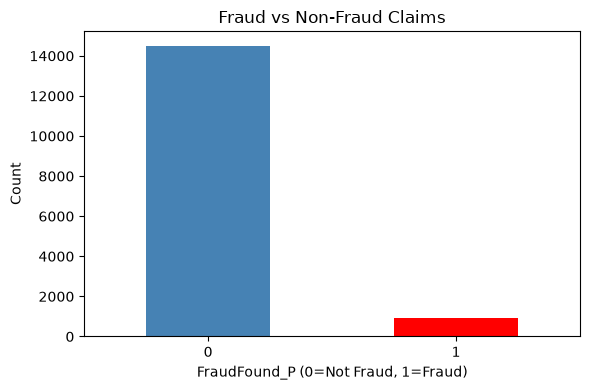

In [7]:
fraud_counts = claims_data['FraudFound_P'].value_counts()
fraud_pct = claims_data['FraudFound_P'].value_counts(normalize=True)*100

print("Fraud Distribution:")
print(fraud_counts)
print("\nPercentage:")
print(fraud_pct.round(2))

plt.figure(figsize=(6,4))
claims_data['FraudFound_P'].value_counts().plot(kind='bar',color=['steelblue','red'])

plt.title("Fraud vs Non-Fraud Claims")
plt.xlabel("FraudFound_P (0=Not Fraud, 1=Fraud)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('fraud_distribution.png',dpi=150)
plt.show()

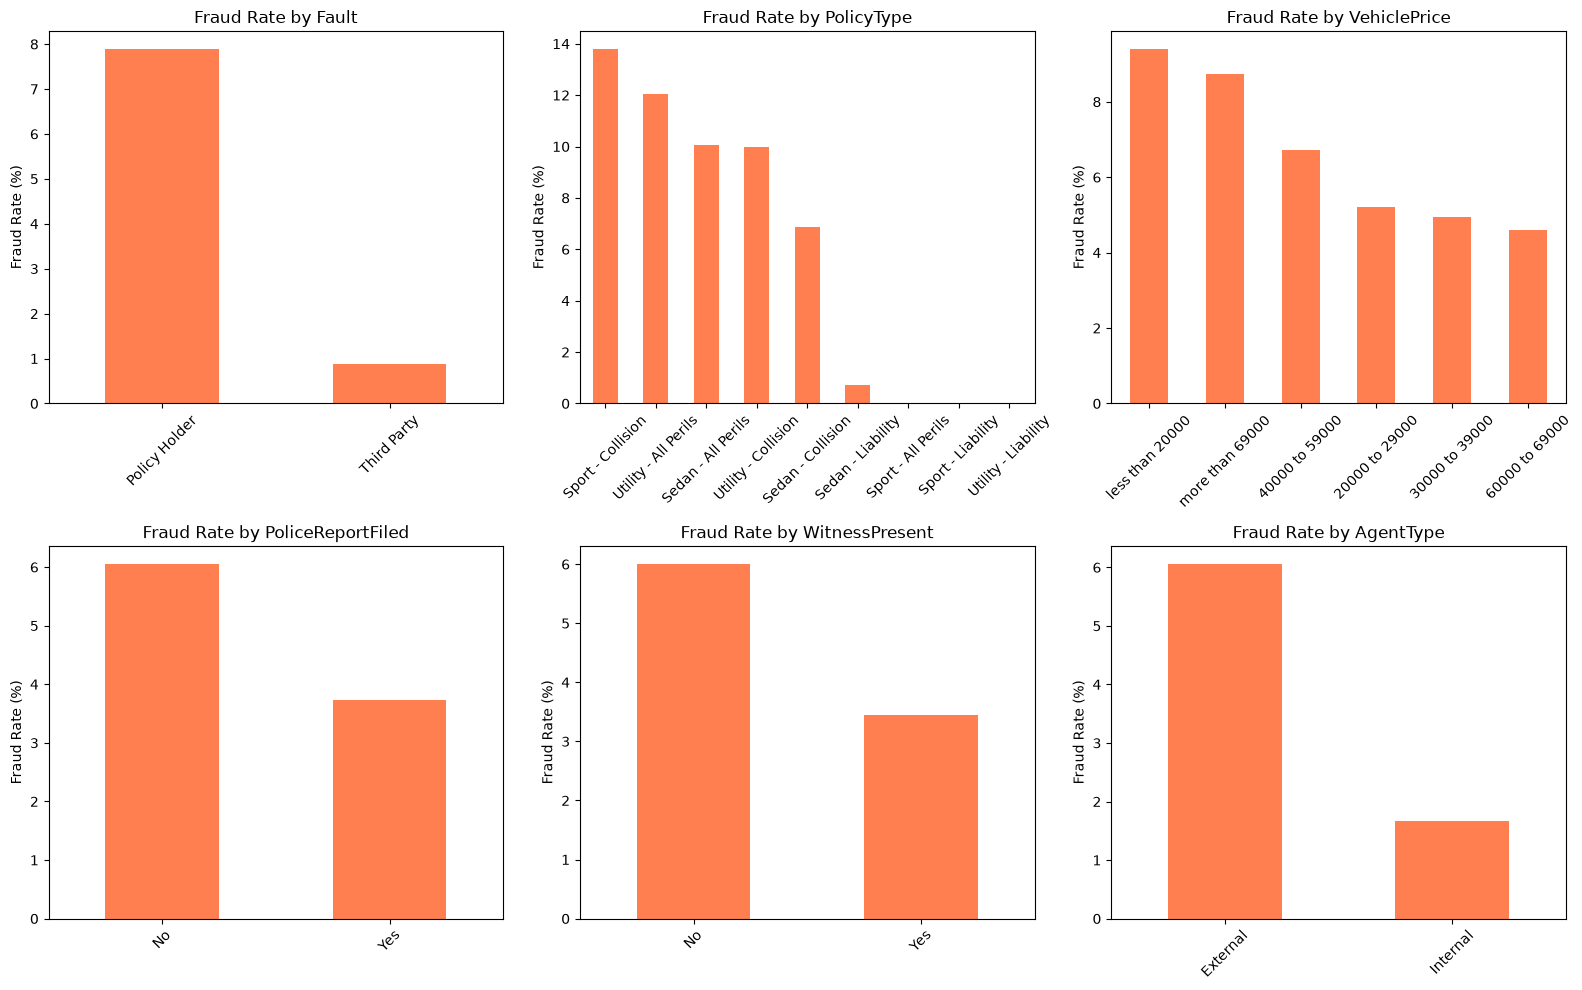

In [8]:
fig, axes = plt.subplots(2,3,figsize=(16,10))
cat_cols = ['Fault','PolicyType', 'VehiclePrice','PoliceReportFiled','WitnessPresent','AgentType']

for ax,col in zip(axes.flatten(), cat_cols):
    fraud_rate = claims_data.groupby(col)['FraudFound_P'].mean()*100
    fraud_rate.sort_values(ascending=False).plot(kind='bar', ax=ax, color='coral')
    ax.set_title(f'Fraud Rate by {col}')
    ax.set_ylabel('Fraud Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("fraud_rate_by_category.png",dpi=150)
plt.show()


In [9]:
# !pip install imbalanced-learn

In [10]:
drop_cols = ['PolicyNumber', 'RepNumber']

df= claims_data.drop(columns=drop_cols)

X = df.drop(columns=['FraudFound_P'])
Y = df['FraudFound_P']

print("Features shape:", X.shape)
print("Target shape:", Y.shape)
print("\nCategorical columns:")
cat_cols = X.select_dtypes(include='str').columns.tolist()
print(cat_cols)
print("\nNumeric Columns:")
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
print(num_cols)

Features shape: (15420, 30)
Target shape: (15420,)

Categorical columns:
['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'BasePolicy']

Numeric Columns:
['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'Deductible', 'DriverRating', 'Year']


### Preprocessing

In [11]:
from sklearn.preprocessing import LabelEncoder

df_encoded = X.copy()
le = LabelEncoder()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

print("Encoding done!")
print(df_encoded.shape)
df_encoded.head()
    

Encoding done!
(15420, 30)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,2,5,6,6,1,6,5,1,0,2,...,1,3,0,0,0,3,0,2,1994,2
1,4,3,6,6,1,2,5,4,1,2,...,4,4,1,0,0,3,3,0,1994,1
2,10,5,0,6,1,5,10,2,1,1,...,5,6,0,0,0,3,3,0,1994,1
3,6,2,2,17,0,1,6,1,1,1,...,6,7,1,0,0,2,3,0,1994,2
4,4,5,1,6,1,6,4,2,0,2,...,3,4,0,0,0,3,3,0,1994,1


In [12]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X_encoded = df_encoded
y_target = Y

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_target , test_size = 0.2, random_state=42, stratify=y_target
)

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state = 42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

Before SMOTE:
FraudFound_P
0    11598
1      738
Name: count, dtype: int64

After SMOTE:
FraudFound_P
0    11598
1    11598
Name: count, dtype: int64


### Model Building

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_sm, y_train_sm)

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:,1]

print("=== Decision Tree Results ===")
print(classification_report(y_test,dt_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, dt_prob):.4f}")


=== Decision Tree Results ===
              precision    recall  f1-score   support

           0       0.98      0.69      0.81      2899
           1       0.14      0.78      0.23       185

    accuracy                           0.70      3084
   macro avg       0.56      0.73      0.52      3084
weighted avg       0.93      0.70      0.78      3084

ROC-AUC Score: 0.7981


In [14]:
# !pip install xgboost

In [15]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators = 100,
    max_depth = 5,
    learning_rate = 0.1,
    random_state = 42,
    eval_metric = 'logloss',
    verbosity = 0
)

xgb_model.fit(X_train_sm, y_train_sm)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

print("=== XGBoost Results ===")
print(classification_report(y_test,xgb_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, xgb_prob):.4f}")



=== XGBoost Results ===
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      2899
           1       0.18      0.42      0.25       185

    accuracy                           0.85      3084
   macro avg       0.57      0.65      0.59      3084
weighted avg       0.91      0.85      0.88      3084

ROC-AUC Score: 0.8112


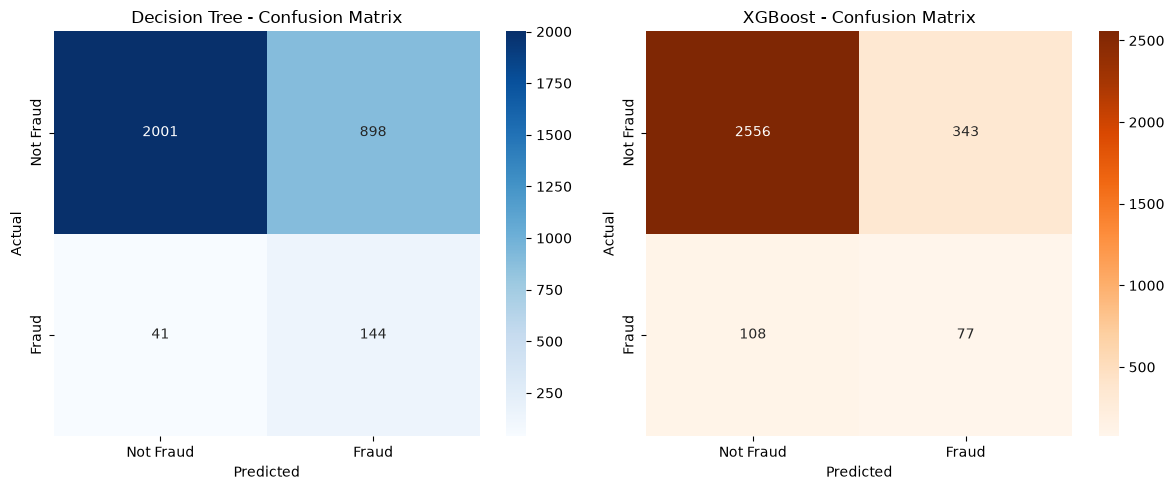

In [16]:
fig, axes = plt.subplots(1, 2, figsize = (12,5))
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels = ['Not Fraud', 'Fraud'],
            yticklabels = ['Not Fraud', 'Fraud'])
axes[0].set_title('Decision Tree - Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

#xgboost
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels = ['Not Fraud', 'Fraud'],
            yticklabels = ['Not Fraud', 'Fraud'])
axes[1].set_title('XGBoost - Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png',dpi = 150)
plt.show()

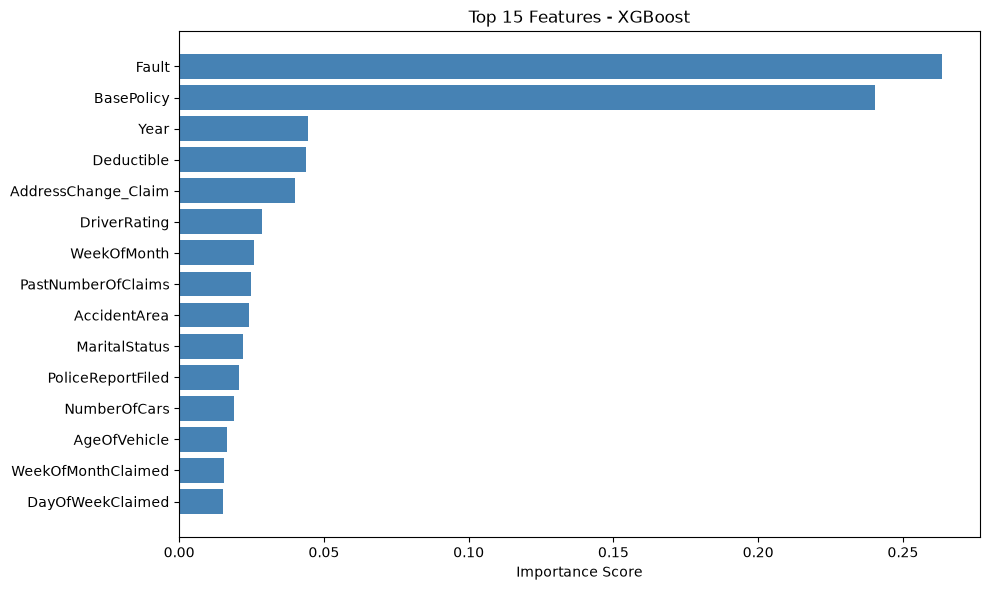

                feature  importance
11                Fault    0.263445
29           BasePolicy    0.240406
28                 Year    0.044666
15           Deductible    0.043644
26  AddressChange_Claim    0.039848
16         DriverRating    0.028608
1           WeekOfMonth    0.025686
19   PastNumberOfClaims    0.024759
4          AccidentArea    0.024162
9         MaritalStatus    0.021973
22    PoliceReportFiled    0.020729
27         NumberOfCars    0.019024
20         AgeOfVehicle    0.016607
7    WeekOfMonthClaimed    0.015578
5      DayOfWeekClaimed    0.015285


In [17]:
feature_importance = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance':xgb_model.feature_importances_
}).sort_values('importance',ascending=False).head(15)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['feature'],
         feature_importance['importance'],
         color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 15 Features - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png',dpi=150)
plt.show()

print(feature_importance)

In [18]:
# Drop Year column - low variation, not meaningful
X_encoded_clean = df_encoded.drop(columns=['Year'])

# Redo train test split and SMOTE with clean data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded_clean, y_target, test_size=0.2, random_state=42, stratify=y_target
)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("Done — Year column removed, SMOTE reapplied")

Done — Year column removed, SMOTE reapplied


In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_sm, y_train_sm)
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

print("=== Decision Tree ===")
print(classification_report(y_test, dt_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, dt_prob):.4f}\n")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_sm, y_train_sm)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}\n")

# XGBoost
xgb_model = XGBClassifier(
    n_estimators=100, max_depth=5, learning_rate=0.1,
    random_state=42, eval_metric='logloss', verbosity=0
)
xgb_model.fit(X_train_sm, y_train_sm)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, xgb_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_prob):.4f}")

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.97      0.67      0.79      2899
           1       0.12      0.72      0.21       185

    accuracy                           0.67      3084
   macro avg       0.55      0.70      0.50      3084
weighted avg       0.92      0.67      0.76      3084

ROC-AUC: 0.7934

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      2899
           1       0.18      0.19      0.19       185

    accuracy                           0.90      3084
   macro avg       0.57      0.57      0.57      3084
weighted avg       0.90      0.90      0.90      3084

ROC-AUC: 0.7983

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.96      0.87      0.91      2899
           1       0.16      0.38      0.22       185

    accuracy                           0.84      3084
   macro avg       0.56      0.62 

           Model  Accuracy  ROC-AUC
0  Decision Tree    0.6735   0.7934
1  Random Forest    0.9011   0.7983
2        XGBoost    0.8408   0.7976


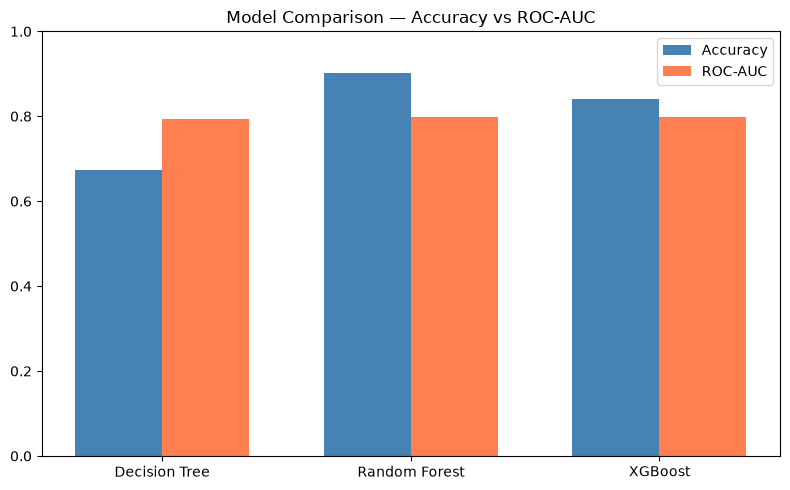

In [20]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        (dt_pred == y_test).mean(),
        (rf_pred == y_test).mean(),
        (xgb_pred == y_test).mean()
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

comparison = comparison.round(4)
print(comparison)

# Visualize comparison
fig, ax = plt.subplots(figsize=(8, 5))
x = range(len(comparison))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], comparison['Accuracy'], 
               width, label='Accuracy', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], comparison['ROC-AUC'], 
               width, label='ROC-AUC', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.set_ylim(0, 1)
ax.set_title('Model Comparison — Accuracy vs ROC-AUC')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

### Evaluation

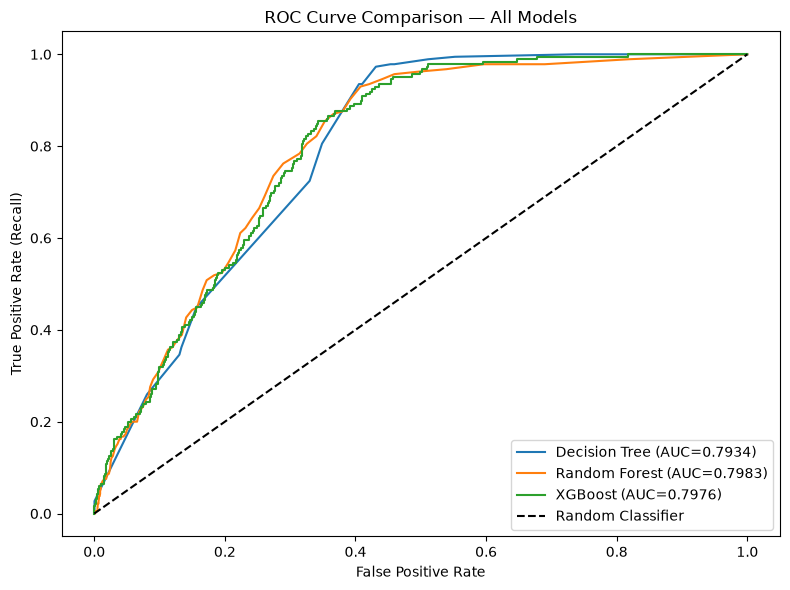

In [21]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, prob in [('Decision Tree', dt_prob), 
                    ('Random Forest', rf_prob), 
                    ('XGBoost', xgb_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison — All Models')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

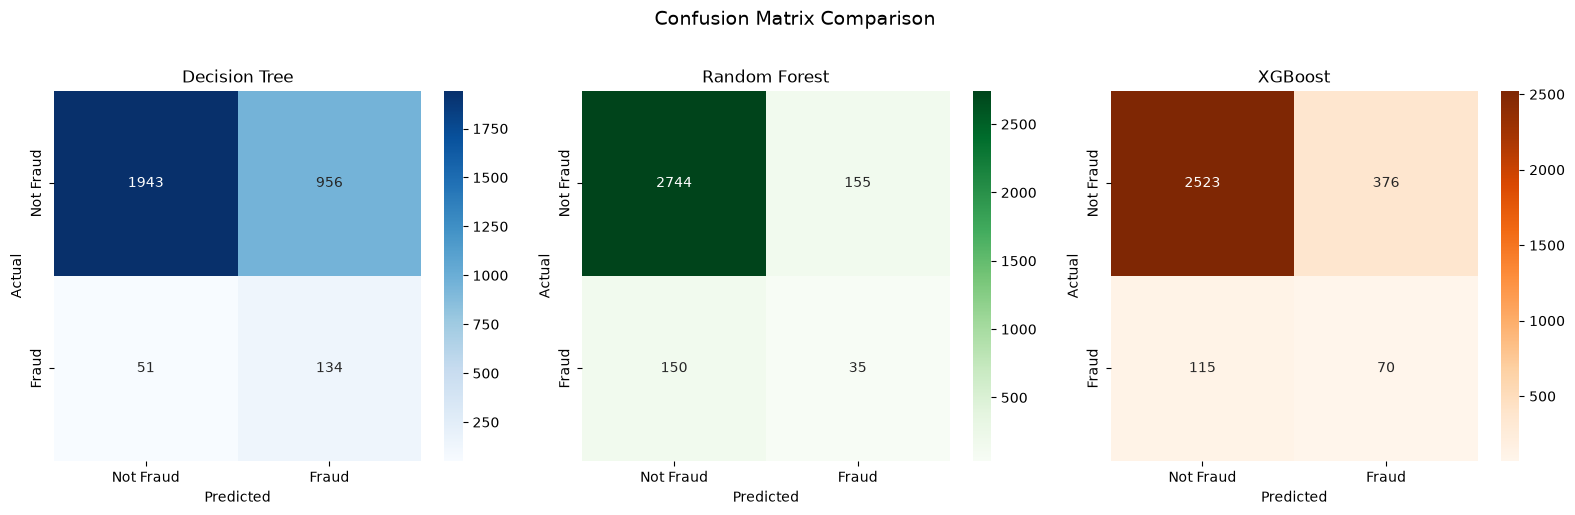

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = [('Decision Tree', dt_pred), 
          ('Random Forest', rf_pred), 
          ('XGBoost', xgb_pred)]
colors = ['Blues', 'Greens', 'Oranges']

for ax, (name, pred), cmap in zip(axes, models, colors):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Not Fraud', 'Fraud'],
                yticklabels=['Not Fraud', 'Fraud'])
    ax.set_title(f'{name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices_all.png', dpi=150)
plt.show()

In [23]:
from sklearn.metrics import average_precision_score, precision_recall_curve, f1_score

def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"=== {name} ===")
    print(classification_report(y_true, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
    print(f"PR-AUC (Average Precision): {average_precision_score(y_true, y_prob):.4f}")
    print()

### Optimisation of Model

In [24]:
drop_cols = ['PolicyNumber', 'RepNumber']
df = claims_data.drop(columns=drop_cols)

X = df.drop(columns=['FraudFound_P'])
Y = df['FraudFound_P']

cat_cols = X.select_dtypes(include='str').columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# One-hot encode categoricals instead of label encoding
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Shape after one-hot encoding:", X_encoded.shape)

Shape after one-hot encoding: (15420, 122)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, Y, test_size=0.2, random_state=42, stratify=Y
)

print("Train fraud rate:", y_train.mean())
print("Test fraud rate:", y_test.mean())

Train fraud rate: 0.05982490272373541
Test fraud rate: 0.05998702983138781


In [26]:
from imblearn.combine import SMOTETomek
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- Strategy A: SMOTE (what you had) ---
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# --- Strategy B: SMOTE + Tomek links (cleans overlapping synthetic points) ---
smote_tomek = SMOTETomek(random_state=42)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train, y_train)

# --- Strategy C: class_weight='balanced', no resampling ---
# (used directly in the model below, no separate dataset needed)

In [27]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [1, (y_train==0).sum()/(y_train==1).sum()]  # handles imbalance directly
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb_base, param_distributions=param_dist,
    n_iter=30, scoring='average_precision',  # optimize for PR-AUC, not accuracy
    cv=cv, random_state=42, n_jobs=-1, verbose=1
)

# Fit on SMOTE-resampled data (try this on X_train_sm, or on raw X_train
# if you use scale_pos_weight instead of SMOTE — don't combine both)
search.fit(X_train_sm, y_train_sm)

print("Best params:", search.best_params_)
print("Best CV PR-AUC:", search.best_score_)

xgb_tuned = search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.9, 'scale_pos_weight': 1, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV PR-AUC: 0.9936533463369248


In [28]:
xgb_prob = xgb_tuned.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"Precision at best threshold: {precisions[best_idx]:.3f}")
print(f"Recall at best threshold: {recalls[best_idx]:.3f}")
print(f"F1 at best threshold: {f1_scores[best_idx]:.3f}")

xgb_pred_tuned = (xgb_prob >= best_threshold).astype(int)
evaluate_model("XGBoost (tuned + threshold-optimized)", y_test, xgb_pred_tuned, xgb_prob)

# Compare against default threshold
xgb_pred_default = xgb_tuned.predict(X_test)
evaluate_model("XGBoost (tuned, default 0.5 threshold)", y_test, xgb_pred_default, xgb_prob)

Best threshold: 0.091
Precision at best threshold: 0.204
Recall at best threshold: 0.654
F1 at best threshold: 0.311
=== XGBoost (tuned + threshold-optimized) ===
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      2899
           1       0.20      0.65      0.31       185

    accuracy                           0.83      3084
   macro avg       0.59      0.75      0.61      3084
weighted avg       0.93      0.83      0.86      3084

ROC-AUC: 0.8396
PR-AUC (Average Precision): 0.2168

=== XGBoost (tuned, default 0.5 threshold) ===
              precision    recall  f1-score   support

           0       0.94      0.99      0.96      2899
           1       0.24      0.07      0.11       185

    accuracy                           0.93      3084
   macro avg       0.59      0.53      0.54      3084
weighted avg       0.90      0.93      0.91      3084

ROC-AUC: 0.8396
PR-AUC (Average Precision): 0.2168



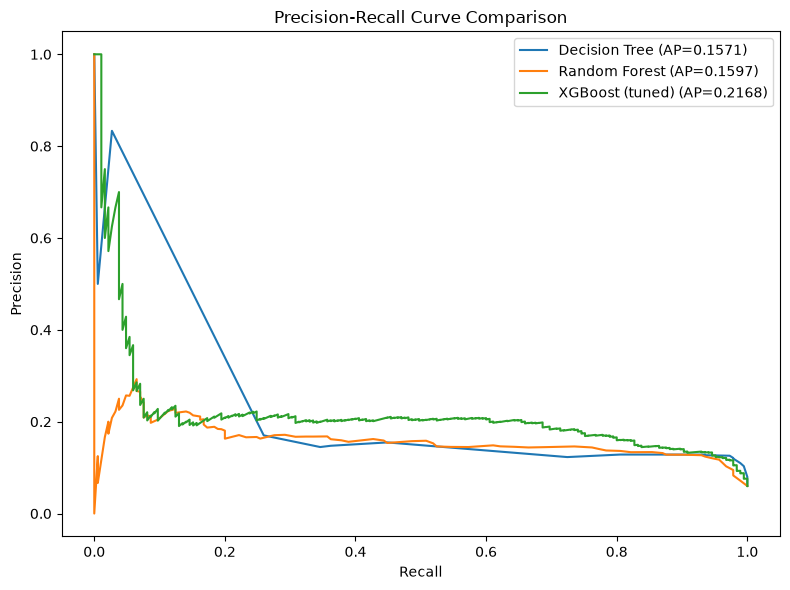

In [29]:
plt.figure(figsize=(8, 6))

for name, prob in [('Decision Tree', dt_prob),
                    ('Random Forest', rf_prob),
                    ('XGBoost (tuned)', xgb_prob)]:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(rec, prec, label=f'{name} (AP={ap:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.tight_layout()
plt.savefig('pr_curve.png', dpi=150)
plt.show()